1. Import và setup path

In [19]:
import sys
import random
from pathlib import Path
from subprocess import run

import cv2
import matplotlib.pyplot as plt
import torch
import xml.etree.ElementTree as ET
from collections import Counter

ROOT = Path.cwd()
for parent in [ROOT] + list(ROOT.parents):
    if (parent / "src").exists():
        PROJECT_ROOT = parent
        break
else:
    raise RuntimeError("Không tìm thấy project root")

sys.path.append(str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

from src import CellPipeline, WBCProposal, load_wbc_classifier, load_rbc_detector
from src.annotation_converter import AnnotationConverter

Project root: f:\py\XLAS\HeaWeb
Device: cpu


2. Khai báo đường dẫn dataset

In [20]:
DATASET_MASTER = PROJECT_ROOT / "dataset-master" / "dataset-master"
DATASET2_MASTER = PROJECT_ROOT / "dataset2-master" / "dataset2-master"

JPEG_DIR = DATASET_MASTER / "JPEGImages"
ANNOTATION_DIR = DATASET_MASTER / "Annotations"
DATASET2_IMAGES = DATASET2_MASTER / "images"

print("JPEG_DIR:", JPEG_DIR.exists(), JPEG_DIR)
print("ANNOTATION_DIR:", ANNOTATION_DIR.exists(), ANNOTATION_DIR)
print("DATASET2_IMAGES:", DATASET2_IMAGES.exists(), DATASET2_IMAGES)

JPEG_DIR: True f:\py\XLAS\HeaWeb\dataset-master\dataset-master\JPEGImages
ANNOTATION_DIR: True f:\py\XLAS\HeaWeb\dataset-master\dataset-master\Annotations
DATASET2_IMAGES: True f:\py\XLAS\HeaWeb\dataset2-master\dataset2-master\images


3. Kiểm tra XML annotation đang là RBC

In [18]:
names = []

for xml_path in sorted(ANNOTATION_DIR.glob("*.xml")):
    root = ET.parse(xml_path).getroot()
    for obj in root.findall("object"):
        name = obj.find("name").text
        names.append(name)

counter = Counter(names)
print(counter)
counter

Counter({'RBC': 3854})


Counter({'RBC': 3854})

4. Hiển thị một ảnh mẫu bất kỳ

Sample image: f:\py\XLAS\HeaWeb\dataset-master\dataset-master\JPEGImages\BloodImage_00028.jpg


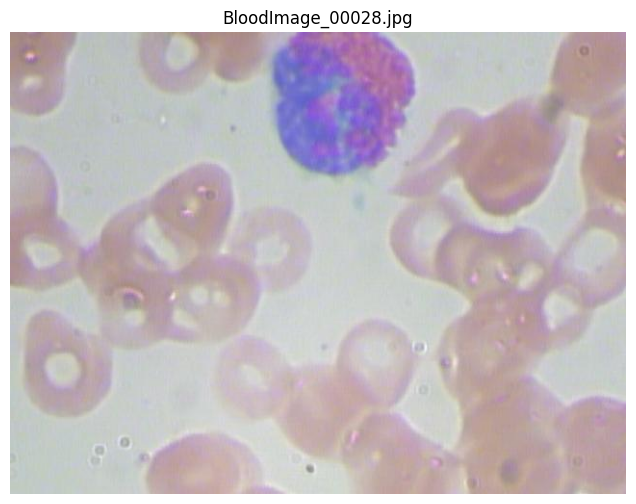

In [30]:
jpg_files = sorted(JPEG_DIR.glob("*.jpg"))
if not jpg_files:
    raise FileNotFoundError(f"Không tìm thấy ảnh .jpg trong {JPEG_DIR}")

sample_image = random.choice(jpg_files)
img_bgr = cv2.imread(str(sample_image))
if img_bgr is None:
    raise FileNotFoundError(f"Không đọc được ảnh: {sample_image}")
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

print("Sample image:", sample_image)

plt.figure(figsize=(8, 6))
plt.imshow(img_rgb)
plt.title(sample_image.name)
plt.axis("off")
plt.show()


5. Test WBC proposal bằng xử lý ảnh số

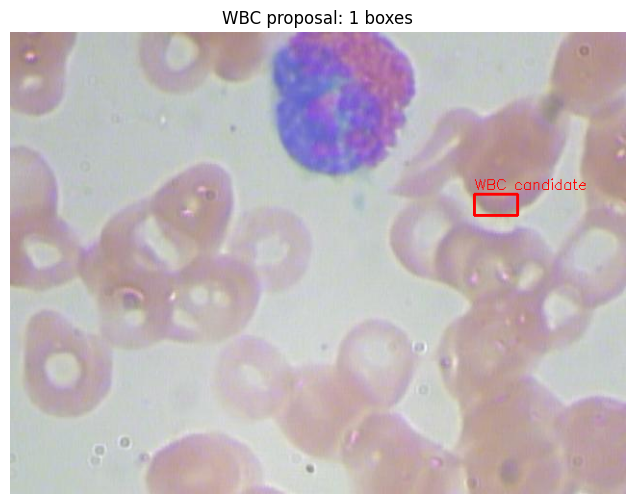

[[482, 168, 527, 190]]

In [31]:
proposal = WBCProposal()
wbc_boxes = proposal.propose(img_bgr)

vis = img_bgr.copy()

for x1, y1, x2, y2 in wbc_boxes:
    cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 0, 255), 2)
    cv2.putText(vis, "WBC candidate", (x1, max(0, y1 - 5)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)

plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title(f"WBC proposal: {len(wbc_boxes)} boxes")
plt.axis("off")
plt.show()

wbc_boxes[:10]


6.  Crop các vùng WBC candidate

Number of crops: 1


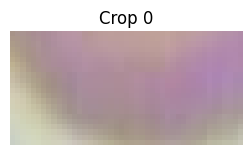

In [32]:
crops = proposal.crop_boxes(img_bgr, wbc_boxes)

print("Number of crops:", len(crops))

for i, crop in enumerate(crops[:6]):
    plt.figure(figsize=(3, 3))
    plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
    plt.title(f"Crop {i}")
    plt.axis("off")
    plt.show()

7. Khai báo đường dẫn model weights

In [ ]:
# Điền sau khi train xong model
RBC_WEIGHTS = HealWeb / "saved_models" / "rbc_yolo" / "weights" / "best.pt"
WBC_WEIGHTS = HealWeb / "saved_models" / "wbc_classifier_best.pth"

8. Load WBC classifier nếu đã có weights

In [33]:
device = "cuda" if torch.cuda.is_available() else "cpu"

wbc_model = None
wbc_class_names = ["NEUTROPHIL", "LYMPHOCYTE", "MONOCYTE", "EOSINOPHIL", "BASOPHIL"]

if WBC_WEIGHTS is not None and Path(WBC_WEIGHTS).exists():
    wbc_model, wbc_class_names, backbone, img_size = load_wbc_classifier(str(WBC_WEIGHTS), device=device)
    print("Loaded WBC classifier:", backbone, img_size, wbc_class_names)
else:
    print("Chưa có WBC classifier weights. Cell này chỉ test proposal/crop.")


Chưa có WBC classifier weights. Cell này chỉ test proposal/crop.


9. Load RBC detector nếu đã có weights

In [34]:
rbc_detector = None
rbc_boxes = []

if RBC_WEIGHTS is not None and Path(RBC_WEIGHTS).exists():
    rbc_detector = load_rbc_detector(
        model_type="yolov5",
        weights=str(RBC_WEIGHTS),
        classes=["RBC"],
        img_size=224,
        device=device,
    )
    print("Loaded RBC detector")
else:
    print("Chưa có RBC detector weights. Pipeline vẫn chạy được phần WBC proposal.")


Chưa có RBC detector weights. Pipeline vẫn chạy được phần WBC proposal.


Vẽ trước RBC ảnh

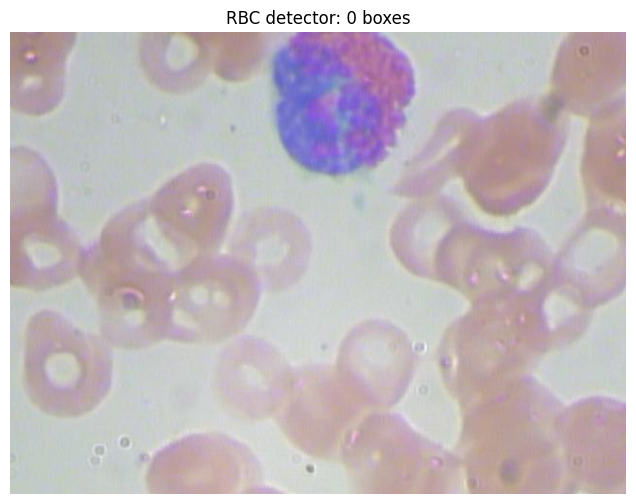

[]

In [40]:
rbc_boxes = []

if rbc_detector is not None:
    preds = rbc_detector.detect([img_bgr])[0]
    if preds is not None and len(preds) > 0:
        rbc_boxes = preds[:, 1:5].tolist()

vis_rbc = img_bgr.copy()
for x1, y1, x2, y2 in rbc_boxes:
    cv2.rectangle(vis_rbc, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)
    cv2.putText(
        vis_rbc,
        "RBC",
        (int(x1), max(0, int(y1) - 5)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0, 255, 0),
        1,
    )

plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(vis_rbc, cv2.COLOR_BGR2RGB))
plt.title(f"RBC detector: {len(rbc_boxes)} boxes")
plt.axis("off")
plt.show()

rbc_boxes[:10]


10. Chạy RBC detector rồi loại RBC khỏi WBC proposal

Bỏ qua phần RBC detector vì chưa có weights.


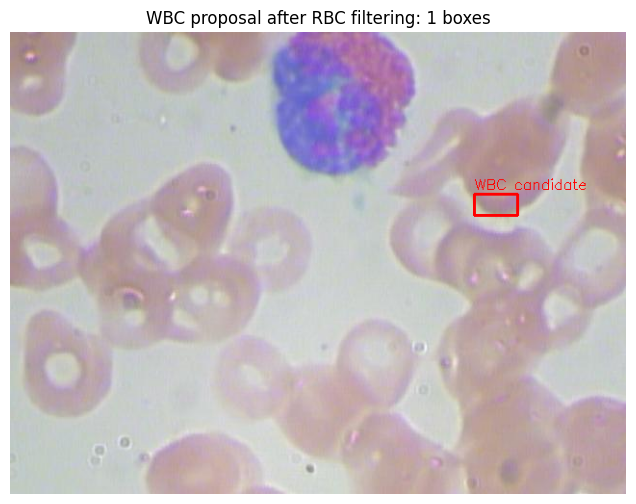

[[482, 168, 527, 190]]

In [35]:
rbc_boxes = []
if rbc_detector is not None:
    preds = rbc_detector.detect([img_bgr])[0]
    if preds is not None and len(preds) > 0:
        rbc_boxes = preds[:, 1:5].tolist()

    vis_rbc = img_bgr.copy()
    for x1, y1, x2, y2 in rbc_boxes:
        cv2.rectangle(vis_rbc, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)
        cv2.putText(
            vis_rbc,
            "RBC",
            (int(x1), max(0, int(y1) - 5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 0),
            1,
        )

    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(vis_rbc, cv2.COLOR_BGR2RGB))
    plt.title(f"RBC detector: {len(rbc_boxes)} boxes")
    plt.axis("off")
    plt.show()
else:
    print("Bỏ qua phần RBC detector vì chưa có weights.")

filtered_wbc_boxes = proposal.propose(img_bgr, exclude_boxes=rbc_boxes)

vis_filtered = img_bgr.copy()
for x1, y1, x2, y2 in filtered_wbc_boxes:
    cv2.rectangle(vis_filtered, (int(x1), int(y1)), (int(x2), int(y2)), (0, 0, 255), 2)
    cv2.putText(
        vis_filtered,
        "WBC candidate",
        (int(x1), max(0, int(y1) - 5)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0, 0, 255),
        1,
    )

plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(vis_filtered, cv2.COLOR_BGR2RGB))
plt.title(f"WBC proposal after RBC filtering: {len(filtered_wbc_boxes)} boxes")
plt.axis("off")
plt.show()

filtered_wbc_boxes[:10]


11. Chạy pipeline end-to-end

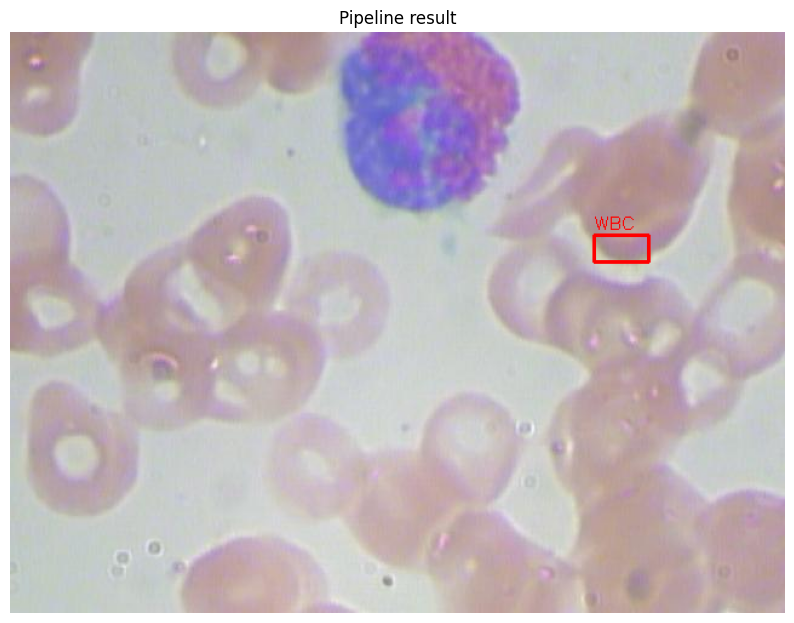

RBC boxes: 0
WBC boxes: 1
WBC predictions: []


In [36]:
pipeline = CellPipeline(
    rbc_detector=rbc_detector,
    wbc_classifier=wbc_model,
    wbc_class_names=wbc_class_names,
    img_size=224,
    device=device,
)

result = pipeline.run(str(sample_image))
vis = pipeline.draw_result(result)

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title("Pipeline result")
plt.axis("off")
plt.show()

print("RBC boxes:", len(result["rbc_boxes"]))
print("WBC boxes:", len(result["wbc_boxes"]))
print("WBC predictions:", result["wbc_predictions"])


12. Train WBC classifier

In [37]:
run([
    sys.executable,
    "-m",
    "src.train",
    "--task",
    "classification",
    "--train_root",
    str(DATASET2_MASTER / "images" / "TRAIN"),
    "--val_root",
    str(DATASET2_MASTER / "images" / "TEST"),
    "--backbone",
    "resnet18",
    "--img_size",
    "224",
    "--batch_size",
    "16",
    "--epochs",
    "10",
    "--save_dir",
    str(PROJECT_ROOT / "saved_models"),
], check=True)


CalledProcessError: Command '['c:\\Users\\Admin\\AppData\\Local\\Programs\\Python\\Python313\\python.exe', '-m', 'src.train', '--task', 'classification', '--train_root', 'f:\\py\\XLAS\\HeaWeb\\dataset2-master\\dataset2-master\\images\\TRAIN', '--val_root', 'f:\\py\\XLAS\\HeaWeb\\dataset2-master\\dataset2-master\\images\\TEST', '--backbone', 'resnet18', '--img_size', '224', '--batch_size', '16', '--epochs', '10', '--save_dir', 'f:\\py\\XLAS\\HeaWeb\\saved_models']' returned non-zero exit status 1.

13. Convert annotation và train RBC detector

In [38]:
converter = AnnotationConverter(
    annotations_dir=str(ANNOTATION_DIR),
    output_dir=str(DATASET_MASTER / "YOLO_labels"),
    classes=["RBC"],
)
df = converter.convert_all_xml()
print(df["class_id"].value_counts().sort_index())

run([
    sys.executable,
    "-m",
    "src.train",
    "--task",
    "detection",
    "--model",
    "yolov5",
    "--img_dir",
    str(JPEG_DIR),
    "--ann_file",
    str(DATASET_MASTER / "YOLO_labels" / "annotations_converted.csv"),
    "--classes",
    "RBC",
    "--epochs",
    "10",
    "--batch_size",
    "4",
    "--img_size",
    "224",
    "--save_dir",
    str(PROJECT_ROOT / "saved_models"),
], check=True)


[INFO] Saved converted annotations to f:\py\XLAS\HeaWeb\dataset-master\dataset-master\YOLO_labels\annotations_converted.csv
class_id
0    3854
Name: count, dtype: int64


CalledProcessError: Command '['c:\\Users\\Admin\\AppData\\Local\\Programs\\Python\\Python313\\python.exe', '-m', 'src.train', '--task', 'detection', '--model', 'yolov5', '--img_dir', 'f:\\py\\XLAS\\HeaWeb\\dataset-master\\dataset-master\\JPEGImages', '--ann_file', 'f:\\py\\XLAS\\HeaWeb\\dataset-master\\dataset-master\\YOLO_labels\\annotations_converted.csv', '--classes', 'RBC', '--epochs', '10', '--batch_size', '4', '--img_size', '224', '--save_dir', 'f:\\py\\XLAS\\HeaWeb\\saved_models']' returned non-zero exit status 1.